<a href="https://colab.research.google.com/github/aisyahkurnia-25/Prediksi-Kualitas-Anggur-Dataset-Wine-Quality/blob/main/Prediksi_Kualitas_Anggur_PDAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Prediksi Kualitas Anggur dengan Random Forest pada Dataset Wine Quality**

**Import Library**

In [112]:
# Library dasar
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Pada tahap ini dilakukan import library yang digunakan selama proses analisis data dan pemodelan machine learning.

- pandas dan numpy digunakan untuk pengolahan data numerik dan tabular.

- matplotlib dan seaborn digunakan untuk visualisasi data, khususnya confusion matrix.

- train_test_split digunakan untuk membagi data menjadi data training dan validation.

- StandardScaler digunakan untuk melakukan feature scaling agar rentang antar fitur menjadi lebih seragam.

- RandomForestClassifier digunakan sebagai model klasifikasi untuk memprediksi kualitas wine.

- Metrik evaluasi seperti accuracy, confusion matrix, dan classification report digunakan untuk mengukur performa model.

**Load Dataset**

In [113]:
# Load data training
train = pd.read_csv('data_training.csv')

# Load data testing
test = pd.read_csv('data_testing.csv')

# Melihat data awal
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Dataset training dan testing berhasil dimuat menggunakan pandas.read_csv().
Dataset training berisi fitur-fitur kimia wine beserta label kualitas (quality), sedangkan dataset testing hanya berisi fitur tanpa label kualitas sehingga nantinya digunakan untuk prediksi.

Berdasarkan tampilan lima data pertama, dataset memiliki beberapa variabel kimia seperti:

- fixed acidity

- volatile acidity

- citric acid

- alcohol

- sulphates

- dan lain-lain

serta variabel target yaitu quality.

**Exploratory Data Analysis (EDA)**

In [114]:
# Ukuran dataset
print(train.shape)

# Info dataset
train.info()

# Statistik deskriptif
train.describe()

(857, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Berdasarkan hasil EDA diperoleh bahwa dataset training memiliki ukuran:

- 857 baris data

- 13 kolom variabel

Terdapat:

- 11 variabel numerik bertipe float

- 2 variabel bertipe int

Variabel target pada penelitian ini adalah quality.

Berdasarkan statistik deskriptif:

- rata-rata kualitas wine (quality) sebesar 5.65

- nilai kualitas minimum adalah 3

- nilai kualitas maksimum adalah 8

Selain itu terlihat bahwa beberapa fitur memiliki rentang nilai yang cukup berbeda, misalnya:

- total sulfur dioxide memiliki nilai maksimum 278
- sedangkan chlorides hanya sekitar 0.611

Perbedaan skala ini menjadi alasan dilakukannya feature scaling.

In [115]:
# Cek Missing Value
train.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Hasil pengecekan missing value menunjukkan bahwa seluruh variabel memiliki nilai kosong sebanyak 0. Dengan demikian dataset tidak memiliki missing value sehingga tidak diperlukan proses imputasi maupun penghapusan data.

**Memisahkan Fitur dan Target**

In [116]:
X = train.drop('quality', axis=1)
y = train['quality']

Pada tahap ini dataset dipisahkan menjadi:

- X sebagai fitur atau variabel independen

- y sebagai target atau variabel dependen yaitu quality

Variabel quality dipilih sebagai target karena tujuan analisis adalah memprediksi kualitas wine berdasarkan karakteristik kimianya.

**Split Data Training dan Testing Internal**

In [117]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Dataset dibagi menjadi:

- 80% data training

- 20% data validation

Pembagian data dilakukan menggunakan train_test_split() agar model dapat dievaluasi pada data yang belum pernah dilihat sebelumnya.

Parameter:

- random_state=42 digunakan agar hasil pembagian data konsisten

- stratify=y digunakan untuk menjaga proporsi setiap kelas quality tetap seimbang pada data training dan validation.

**Feature Scaling**

In [118]:
scaler = StandardScaler()

# Drop 'Id' from X_train and X_valid before scaling
X_train_scaled = scaler.fit_transform(X_train.drop('Id', axis=1))
X_valid_scaled = scaler.transform(X_valid.drop('Id', axis=1))

# For the original test data, 'Id' is already being dropped correctly
X_test_scaled = scaler.transform(test.drop('Id', axis=1))

Feature scaling dilakukan menggunakan StandardScaler() untuk menyeragamkan skala antar fitur.

StandardScaler bekerja dengan mengubah data sehingga:

- memiliki rata-rata 0

- standar deviasi 1

Kolom Id dihapus karena hanya berfungsi sebagai identitas data dan tidak memiliki pengaruh terhadap kualitas wine.

Feature scaling dilakukan karena beberapa fitur memiliki rentang nilai yang berbeda cukup jauh sehingga dikhawatirkan mempengaruhi performa model.

**Membuat Model**

In [140]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    random_state=42
)

rf.fit(X_train_scaled, y_train)

RandomForestClassifier(max_depth=20, n_estimators=600, random_state=42)

Model yang digunakan adalah RandomForestClassifier.

Random Forest merupakan algoritma ensemble berbasis decision tree yang bekerja dengan membangun banyak pohon keputusan kemudian menggabungkan hasil prediksi dari seluruh pohon.

Parameter yang digunakan:

- n_estimators=600 → jumlah pohon keputusan sebanyak 600

- max_depth=20 → kedalaman maksimum setiap pohon

- random_state=42 → menjaga konsistensi hasil

Model kemudian dilatih menggunakan data training yang telah discaling.

**Evaluasi Model**

In [141]:
y_pred = rf.predict(X_valid_scaled)

Model yang telah dilatih digunakan untuk memprediksi data validation. Hasil prediksi disimpan dalam variabel y_pred.

In [143]:
# Akurasi:
acc = accuracy_score(y_valid, y_pred)
print("Accuracy :", acc)

Accuracy : 0.627906976744186


Berdasarkan hasil evaluasi diperoleh accuracy sebesar 62.79%.

Hal ini menunjukkan bahwa model mampu memprediksi kualitas wine dengan benar sekitar 63% dari total data validation.

Nilai accuracy tersebut tergolong cukup baik mengingat dataset memiliki beberapa kelas minoritas dengan jumlah data yang sangat sedikit.

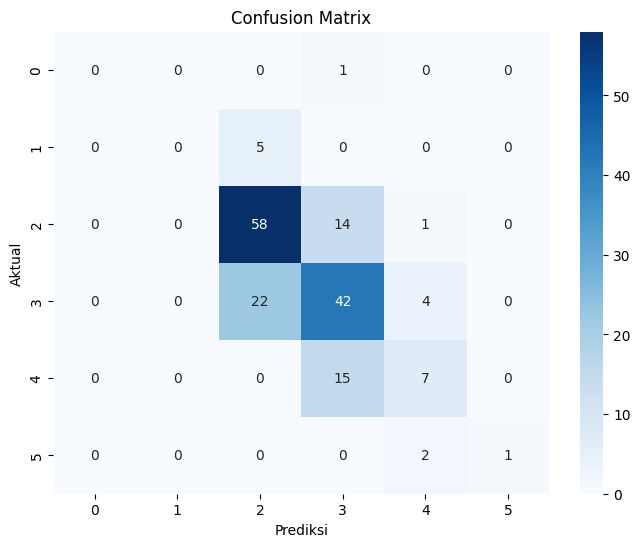

In [144]:
# Confusion matrix
cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

Confusion matrix digunakan untuk melihat performa model pada masing-masing kelas quality.

Berdasarkan confusion matrix terlihat bahwa:

- model cukup baik dalam memprediksi quality 5 dan 6

- model masih kesulitan mengenali quality 3 dan 4 karena jumlah datanya sangat sedikit

Sebagian besar prediksi benar berada pada diagonal utama confusion matrix.

In [145]:
# Classification report
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.68      0.79      0.73        73
           6       0.58      0.62      0.60        68
           7       0.50      0.32      0.39        22
           8       1.00      0.33      0.50         3

    accuracy                           0.63       172
   macro avg       0.46      0.34      0.37       172
weighted avg       0.60      0.63      0.61       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification report menunjukkan nilai:

- precision

- recall

- f1-score

untuk setiap kelas quality.

Hasil menunjukkan:

- kelas 5 memiliki performa terbaik dengan f1-score 0.73

- kelas 6 juga cukup baik dengan f1-score 0.60

- kelas 3 dan 4 memiliki performa rendah karena jumlah datanya sangat sedikit

Nilai weighted average f1-score sebesar 0.61 menunjukkan bahwa model memiliki performa yang cukup baik secara keseluruhan.

**Prediksi Data Testing**

In [142]:
pred_test = rf.predict(X_test_scaled)

Model yang telah dilatih digunakan untuk memprediksi kualitas wine pada dataset testing yang tidak memiliki label quality.

Hasil prediksi disimpan dalam variabel pred_test.

**Membuat File Submission**

In [146]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'quality': pred_test
})

submission.head()

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5


**Export CSV**

In [147]:
submission.to_csv('hasilprediksi_015.csv', index=False)

**Download File**

In [148]:
from google.colab import files
files.download('hasilprediksi_015.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Kesimpulan**

Berdasarkan analisis yang telah dilakukan menggunakan algoritma Random Forest Classifier diperoleh accuracy sebesar 62.79%. Model mampu memprediksi kualitas wine dengan cukup baik terutama pada kelas mayoritas seperti quality 5 dan 6. Namun model masih mengalami kesulitan dalam memprediksi kelas minoritas karena jumlah data yang sangat sedikit. Selanjutnya model digunakan untuk memprediksi kualitas wine pada dataset testing dan hasil prediksi berhasil disimpan dalam format CSV sesuai ketentuan tugas.